# Step 13 – Technology-Type Interaction Regression (RQ5)

**Research question:** Do the effects of city characteristics on the diffusion
speed of prominent open-AI projects vary across technology types?

**Design:**
- 7-class technology taxonomy (LLM split into Foundation / Application /
  NLP-Traditional, plus Vision, Agent, Multimodal, Speech/Audio).
- DV: `log1p(interval)` — inter-event interval (IEI), consistent with
  Step 11's definition of diffusion speed.
- IV: 9 city features × 6 tech-type dummies = **54 interaction terms**,
  plus 9 main effects + 6 tech dummies + controls.
- Main specification: **OLS** (ordinary least squares).

In [27]:
import warnings, textwrap
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120})

DATA = Path('..') / 'data' / 'output'
PROC = Path('..') / 'data' / 'processed'

city_attr  = pd.read_csv(DATA / 'city_attributes.csv')
adoption   = pd.read_csv(DATA / 'city_project_adoption_events.csv')
prom       = pd.read_csv(PROC / 'prominent_projects_master.csv')

print(f'city_attributes : {city_attr.shape}')
print(f'adoption_events : {adoption.shape}')
print(f'prominent_proj  : {prom.shape}')

city_attributes : (148, 28)
adoption_events : (39158, 6)
prominent_proj  : (23481, 15)


---
## 13.1 – Technology-Type Classification (7 classes)

In [28]:
# ── keyword sets (priority order: rarest first) ──────────────────────
MULTIMODAL_KW = {'multimodal', 'image-text-to-text',
                 'visual-question-answering', 'document-question-answering',
                 'image-to-text', 'any-to-any', 'clip', 'vision-language'}

VISION_KW = {'computer-vision', 'diffusion', 'diffusion-model',
             'stable-diffusion', 'text-to-image', 'image-classification',
             'object-detection', 'image-segmentation', 'image-to-image',
             'depth-estimation', 'unconditional-image-generation',
             'text-to-video', 'video-classification', 'video-generation'}

SPEECH_KW = {'tts', 'text-to-speech', 'whisper',
             'automatic-speech-recognition', 'audio-classification',
             'text-to-audio', 'voice-activity-detection'}

AGENT_KW = {'agent', 'ai-agent'}

NLP_TRAD_KW = {'text-classification', 'token-classification',
               'summarization', 'translation', 'fill-mask',
               'sentence-similarity', 'question-answering',
               'zero-shot-classification', 'table-question-answering'}

LLM_FOUND_KW = {'llama', 'qwen', 'deepseek', 'mistral', 'gemma',
                'large-language-model', 'language-model', 'falcon',
                'bloom', 'gpt-neox', 'phi', 'chatglm', 'glm',
                'rwkv', 'mamba'}

LLM_APP_KW = {'chatgpt', 'gpt', 'rag', 'prompt', 'prompt-engineering',
              'embedding', 'langchain', 'openai', 'chatbot'}

LLM_BROAD_KW = {'llm', 'generative-ai', 'transformer', 'neural-network',
                'deep-learning', 'machine-learning',
                'artificial-intelligence', 'nlp',
                'natural-language-processing', 'conversational',
                'text-generation', 'quantization', 'fine-tuning'}

OTHER_KW = {'reinforcement-learning', 'robotics', 'mlops'}


def classify_tech(row):
    platform = row['platform']
    hf_type  = str(row.get('hf_type', '') or '')
    raw = (str(row.get('ai_evidence', '') or '') + '; '
           + str(row.get('tags', '') or '').replace('|', '; '))
    tags = {t.strip().lower() for t in raw.replace(';', ',').split(',')
            if t.strip()}

    if tags & MULTIMODAL_KW:   return 'Multimodal'
    if tags & VISION_KW:       return 'Vision'
    if tags & SPEECH_KW:       return 'Speech'
    if tags & AGENT_KW:        return 'Agent'
    if tags & NLP_TRAD_KW:     return 'NLP-Traditional'
    if tags & LLM_FOUND_KW:    return 'LLM-Foundation'
    if (platform == 'HuggingFace' and hf_type == 'model'
            and 'text-generation' in tags):
        return 'LLM-Foundation'
    if tags & LLM_APP_KW:      return 'LLM-Application'
    if tags & LLM_BROAD_KW:    return 'LLM-Application'
    if tags & OTHER_KW:        return 'Other'
    if 'task_categories:text-generation' in tags:
        return 'LLM-Application'
    return 'Unclassified'


prom['tech_type'] = prom.apply(classify_tech, axis=1)

VALID_TYPES = ['LLM-Application', 'LLM-Foundation', 'NLP-Traditional',
               'Vision', 'Agent', 'Multimodal', 'Speech']

print('── All prominent projects ──')
print(prom['tech_type'].value_counts().to_string())
print(f'\nValid-type coverage: '
      f'{prom["tech_type"].isin(VALID_TYPES).sum()}/{len(prom)} '
      f'({prom["tech_type"].isin(VALID_TYPES).mean():.1%})')

── All prominent projects ──
tech_type
LLM-Foundation     5842
LLM-Application    5552
Vision             3440
NLP-Traditional    2319
Agent              2240
Multimodal         1926
Speech             1217
Unclassified        670
Other               275

Valid-type coverage: 22536/23481 (96.0%)


In [29]:
# ── map tech_type onto adoption events ────────────────────────────────
proj_type = prom[['full_id', 'project_id', 'tech_type']].copy()
proj_type_by_full = proj_type.set_index('full_id')['tech_type']
proj_type_by_pid  = proj_type.set_index('project_id')['tech_type']
type_map = pd.concat([proj_type_by_full, proj_type_by_pid]).to_dict()

adoption['tech_type'] = adoption['project_id'].map(type_map)

print('── Adoption events by tech_type ──')
print(adoption['tech_type'].value_counts().to_string())
print(f'\nValid-type events: '
      f'{adoption["tech_type"].isin(VALID_TYPES).sum()}/{len(adoption)} '
      f'({adoption["tech_type"].isin(VALID_TYPES).mean():.1%})')

── Adoption events by tech_type ──
tech_type
LLM-Application    11863
Agent               9081
LLM-Foundation      7431
Vision              3997
Multimodal          2854
Speech              1414
NLP-Traditional     1290
Unclassified         858
Other                370

Valid-type events: 37930/39158 (96.9%)


---
## 13.2 – Build Event-Level Regression Table

DV = `log1p(interval)` (inter-event interval, same definition as Step 11 §11.2).

In [30]:
# ── city features (same 9 IVs as Step 10/11) ─────────────────────────
IV_COLS = ['log_degree', 'log_population', 'log_gdp', 'log_entity',
           'education_tertiary_pct', 'internet_users_pct',
           'rd_expenditure_pct', 'research_capacity', 'betweenness']

df_city = city_attr[city_attr['adoption_count'] > 0].copy()
df_city['log_degree']     = np.log1p(df_city['weighted_degree'])
df_city['log_population'] = np.log1p(df_city['population_million'])
df_city['log_gdp']        = np.log(df_city['gdp_per_capita'])
df_city['log_entity']     = np.log1p(df_city['entity_count'])

# ── merge city features onto adoption events ─────────────────────────
df = adoption.merge(df_city[['city'] + IV_COLS], on='city', how='inner')
df = df.dropna(subset=IV_COLS).reset_index(drop=True)

# ── keep only valid tech types ───────────────────────────────────────
df = df[df['tech_type'].isin(VALID_TYPES)].reset_index(drop=True)

# ── compute inter-event interval (same logic as Step 11 §11.2) ──────
def _ym_to_months(ym):
    y, m = divmod(int(ym), 100)
    return (y - 2022) * 12 + (m - 1)

df['_adopt_idx']  = df['city_first_adoption_month'].apply(_ym_to_months)
df['_origin_idx'] = df['global_origin_month'].apply(_ym_to_months)
df = df.sort_values(['project_id', '_adopt_idx', 'city']).reset_index(drop=True)
df['_prev_adopt'] = df.groupby('project_id')['_adopt_idx'].shift(1)
df['interval'] = df['_adopt_idx'] - df['_prev_adopt'].fillna(df['_origin_idx'])

# ── project-level controls (same as Step 11) ─────────────────────────
proj_stats = adoption.groupby('project_id').agg(
    proj_n_cities=('city', 'nunique')).reset_index()
df = df.merge(proj_stats, on='project_id', how='left')
df['log_proj_pop'] = np.log1p(df['proj_n_cities'])
df['proj_origin_idx'] = df['_origin_idx']

prom['metric_stars'] = pd.to_numeric(prom['metric_stars'], errors='coerce')
prom['metric_forks'] = pd.to_numeric(prom['metric_forks'], errors='coerce')
prom['metric_downloads'] = pd.to_numeric(prom['metric_downloads'], errors='coerce')
gh = prom[prom['platform'] == 'GitHub'].copy()
hf = prom[prom['platform'] == 'HuggingFace'].copy()
gh['popularity_pctile'] = gh['metric_stars'].rank(pct=True)
hf['popularity_pctile'] = hf['metric_downloads'].rank(pct=True)
gh['fork_star_ratio'] = gh['metric_forks'] / gh['metric_stars'].replace(0, np.nan)
proj_feats = pd.concat([
    gh[['full_id', 'metric_stars', 'metric_forks', 'popularity_pctile', 'fork_star_ratio']],
    hf[['full_id', 'popularity_pctile']],
]).rename(columns={'full_id': 'project_id'})
proj_feats['log_stars'] = np.log1p(proj_feats['metric_stars'])
proj_feats['log_forks'] = np.log1p(proj_feats['metric_forks'])
df = df.merge(
    proj_feats[['project_id', 'log_stars', 'log_forks',
                'popularity_pctile', 'fork_star_ratio']],
    on='project_id', how='left')

PROJ_CTRL = ['log_proj_pop', 'proj_origin_idx',
             'log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']
for c in PROJ_CTRL:
    df[c] = df[c].fillna(df[c].median())

# ── keep non-originator events (lag > 0) ─────────────────────────────
df = df[df['lag'] > 0].copy()
df['log_interval'] = np.log1p(np.clip(df['interval'], 0, None))

# ── standardise city features for comparable interaction coefficients ─
for c in IV_COLS:
    mu, sd = df[c].mean(), df[c].std()
    df[f'z_{c}'] = (df[c] - mu) / sd if sd > 0 else 0.0

Z_COLS = [f'z_{c}' for c in IV_COLS]

print(f'Events after filtering: {len(df)}')
print(f'Cities: {df["city"].nunique()}')
print(f'Projects: {df["project_id"].nunique()}')
print(f'\nTech-type distribution in regression sample:')
print(df['tech_type'].value_counts().to_string())
print(f'\nProject controls ({len(PROJ_CTRL)}): {PROJ_CTRL}')
print(f'\nInterval (raw):  mean={df["interval"].mean():.2f}, '
      f'median={df["interval"].median():.0f}, std={df["interval"].std():.2f}')
print(f'Interval (log):  mean={df["log_interval"].mean():.2f}, '
      f'std={df["log_interval"].std():.2f}')

Events after filtering: 24434
Cities: 148
Projects: 5405

Tech-type distribution in regression sample:
tech_type
LLM-Application    8476
Agent              7375
LLM-Foundation     3623
Vision             2308
Multimodal         1486
Speech              975
NLP-Traditional     191

Project controls (6): ['log_proj_pop', 'proj_origin_idx', 'log_stars', 'log_forks', 'popularity_pctile', 'fork_star_ratio']

Interval (raw):  mean=2.63, median=1, std=4.39
Interval (log):  mean=0.89, std=0.82


---
## 13.3 – Main Specification: OLS with Interactions

```
log1p(interval)_ij = β₀ + β₁·Z_city_i + β₂·D_tech_j
                   + β₃·(Z_city_i × D_tech_j) + ε_ij
```

- Reference category: **LLM-Application**
- Method: **OLS** (ordinary least squares)
- City features are z-scored so interaction coefficients are comparable

In [31]:
# ── build formula ────────────────────────────────────────────────────
df['tech'] = pd.Categorical(
    df['tech_type'],
    categories=['LLM-Application', 'LLM-Foundation', 'NLP-Traditional',
                'Vision', 'Agent', 'Multimodal', 'Speech'])

tech_dummies = pd.get_dummies(df['tech'], prefix='T', drop_first=True,
                              dtype=float)
tech_dummies.columns = [c.replace('-', '_').replace(' ', '_')
                        for c in tech_dummies.columns]
df = pd.concat([df, tech_dummies], axis=1)

T_COLS = list(tech_dummies.columns)  # 6 dummies

interaction_terms = []
for z in Z_COLS:
    for t in T_COLS:
        col = f'{z}_x_{t}'
        df[col] = df[z] * df[t]
        interaction_terms.append(col)

X_COLS = Z_COLS + T_COLS + interaction_terms + PROJ_CTRL

print(f'Parameters: {len(X_COLS)} IVs + intercept = {len(X_COLS)+1}')
print(f'  City features (z-scored):  {len(Z_COLS)}')
print(f'  Tech dummies:              {len(T_COLS)}')
print(f'  Interaction terms:         {len(interaction_terms)}')
print(f'  Project controls:          {len(PROJ_CTRL)}')
print(f'  Observations:              {len(df)}')
print(f'  Params/obs ratio:          1:{len(df)//(len(X_COLS)+1)}')

Parameters: 75 IVs + intercept = 76
  City features (z-scored):  9
  Tech dummies:              6
  Interaction terms:         54
  Project controls:          6
  Observations:              24434
  Params/obs ratio:          1:321


In [32]:
# ── OLS with city-clustered robust SE ────────────────────────────────
Y = df['log_interval']
X = sm.add_constant(df[X_COLS].astype(float))

ols_model = sm.OLS(Y, X).fit()

print(f'R² = {ols_model.rsquared:.4f},  Adj R² = {ols_model.rsquared_adj:.4f}')
print(f'F-stat = {ols_model.fvalue:.2f},  p = {ols_model.f_pvalue:.2e}')
print(f'Observations = {int(ols_model.nobs)},  df_resid = {int(ols_model.df_resid)}')
print()

# ── Joint F-test: all 54 interaction terms = 0 ───────────────────────
r_matrix = np.zeros((len(interaction_terms), X.shape[1]))
for i, col in enumerate(interaction_terms):
    r_matrix[i, list(X.columns).index(col)] = 1.0

f_test = ols_model.f_test(r_matrix)
print(f'Joint F-test (all 54 interactions = 0):')
print(f'  F({len(interaction_terms)}, {int(ols_model.df_resid)}) = '
      f'{float(f_test.fvalue):.3f},  p = {float(f_test.pvalue):.4e}')

R² = 0.2838,  Adj R² = 0.2816
F-stat = 128.67,  p = 0.00e+00
Observations = 24434,  df_resid = 24358

Joint F-test (all 54 interactions = 0):
  F(54, 24358) = 1.388,  p = 3.1348e-02


In [33]:
# ── Full coefficient table ───────────────────────────────────────────
coef_df = pd.DataFrame({
    'coef':   ols_model.params,
    'se':     ols_model.bse,
    't':      ols_model.tvalues,
    'p':      ols_model.pvalues,
    'ci_lo':  ols_model.conf_int()[0],
    'ci_hi':  ols_model.conf_int()[1],
})

def _stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '†'
    return ''

coef_df['sig'] = coef_df['p'].apply(_stars)
print('── Coefficient Table (OLS) ──')
with pd.option_context('display.max_rows', None, 'display.float_format',
                       '{:.4f}'.format):
    display(coef_df)

── Coefficient Table (OLS) ──


,coef,se,t,p,ci_lo,ci_hi,sig
const,2.3955,0.0339,70.5888,0.0000,2.3289,2.4620,***
z_log_degree,-0.1247,0.0379,-3.2925,0.0010,-0.1989,-0.0505,***
z_log_population,-0.0407,0.0120,-3.3934,0.0007,-0.0643,-0.0172,***
z_log_gdp,0.0118,0.0271,0.4366,0.6624,-0.0413,0.0650,
z_log_entity,0.1043,0.0343,3.0388,0.0024,0.0370,0.1715,**
z_education_tertiary_pct,0.0331,0.0129,2.5760,0.0100,0.0079,0.0584,*
z_internet_users_pct,-0.0488,0.0233,-2.0965,0.0360,-0.0944,-0.0032,*
z_rd_expenditure_pct,-0.0165,0.0111,-1.4797,0.1390,-0.0383,0.0053,
z_research_capacity,0.0072,0.0125,0.5766,0.5642,-0.0173,0.0318,
z_betweenness,-0.0054,0.0107,-0.5053,0.6134,-0.0263,0.0155,


---
## 13.4 – Interaction Coefficient Heatmap

Each cell shows the **total effect** of a city feature for a given tech type
(main effect + interaction), with significance markers.

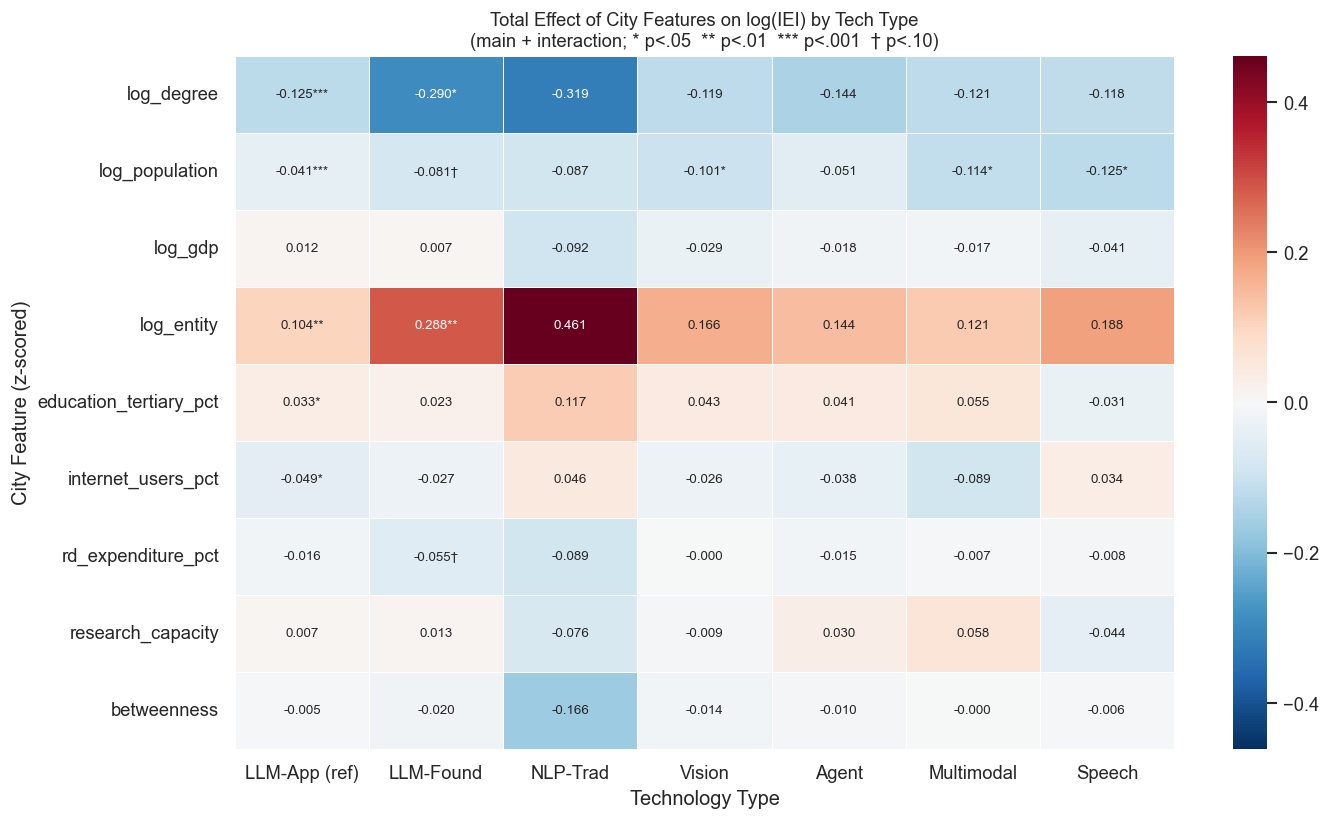

In [34]:
# ── Build total-effect matrix: main_effect + interaction ─────────────
tech_labels = ['LLM-App (ref)', 'LLM-Found', 'NLP-Trad',
               'Vision', 'Agent', 'Multimodal', 'Speech']

effect_matrix = pd.DataFrame(index=IV_COLS, columns=tech_labels,
                             dtype=float)
pval_matrix   = pd.DataFrame(index=IV_COLS, columns=tech_labels,
                             dtype=float)

for iv in IV_COLS:
    z = f'z_{iv}'
    main_b = ols_model.params.get(z, 0.0)
    main_p = ols_model.pvalues.get(z, 1.0)
    effect_matrix.loc[iv, 'LLM-App (ref)'] = main_b
    pval_matrix.loc[iv, 'LLM-App (ref)']   = main_p

    for t_col, t_label in zip(T_COLS, tech_labels[1:]):
        ix_col = f'{z}_x_{t_col}'
        ix_b = ols_model.params.get(ix_col, 0.0)
        ix_p = ols_model.pvalues.get(ix_col, 1.0)
        effect_matrix.loc[iv, t_label] = main_b + ix_b
        pval_matrix.loc[iv, t_label]   = ix_p

effect_matrix = effect_matrix.astype(float)

# ── Heatmap ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

annot = effect_matrix.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        val = effect_matrix.loc[r, c]
        p   = pval_matrix.loc[r, c]
        annot.loc[r, c] = f'{val:.3f}{_stars(p)}'

vmax = max(abs(effect_matrix.values.min()), abs(effect_matrix.values.max()))
sns.heatmap(effect_matrix, annot=annot, fmt='', cmap='RdBu_r',
            center=0, vmin=-vmax, vmax=vmax,
            linewidths=0.5, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Total Effect of City Features on log(IEI) by Tech Type\n'
             '(main + interaction; * p<.05  ** p<.01  *** p<.001  † p<.10)',
             fontsize=11)
ax.set_ylabel('City Feature (z-scored)')
ax.set_xlabel('Technology Type')
plt.tight_layout()
plt.savefig(str(DATA / 'step13_interaction_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 13.5 – Interaction Forest Plot (Significant Terms)

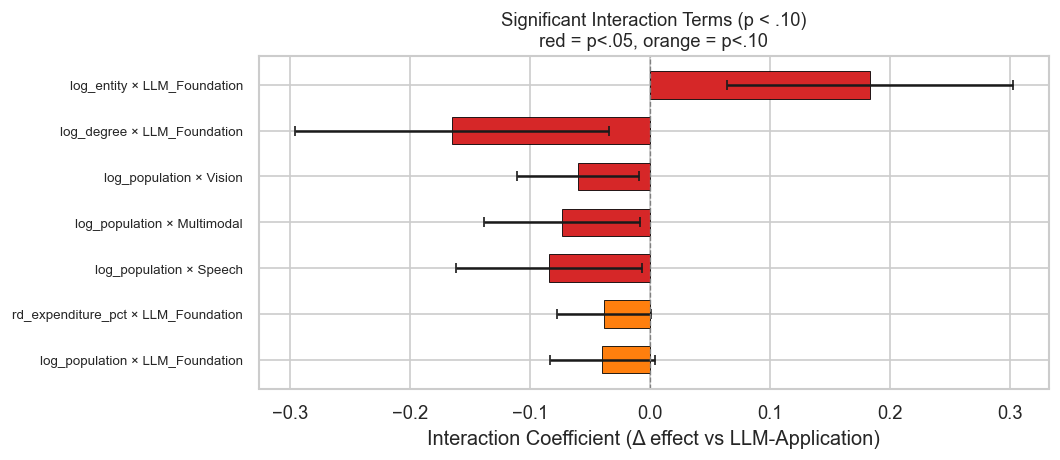


7 interaction terms significant at p < .10
5 significant at p < .05
1 significant at p < .01


In [35]:
# ── Forest plot of significant interaction terms ─────────────────────
ix_df = coef_df.loc[interaction_terms].copy()
ix_df['abs_t'] = ix_df['t'].abs()

sig_ix = ix_df[ix_df['p'] < 0.10].sort_values('abs_t', ascending=True)

if len(sig_ix) == 0:
    print('No interaction terms significant at p < .10')
else:
    fig, ax = plt.subplots(figsize=(9, max(4, len(sig_ix) * 0.35)))
    y_pos = range(len(sig_ix))

    colors = ['#d62728' if p < 0.05 else '#ff7f0e' for p in sig_ix['p']]
    ax.barh(y_pos, sig_ix['coef'], xerr=1.96 * sig_ix['se'],
            color=colors, edgecolor='black', linewidth=0.5, height=0.6,
            capsize=3)
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

    labels = [n.replace('z_', '').replace('_x_T_', ' × ')
              for n in sig_ix.index]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Interaction Coefficient (Δ effect vs LLM-Application)')
    ax.set_title('Significant Interaction Terms (p < .10)\n'
                 'red = p<.05, orange = p<.10', fontsize=11)
    plt.tight_layout()
    plt.savefig(str(DATA / 'step13_interaction_forest.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n{len(sig_ix)} interaction terms significant at p < .10')
    print(f'{(ix_df["p"] < 0.05).sum()} significant at p < .05')
    print(f'{(ix_df["p"] < 0.01).sum()} significant at p < .01')

In [36]:
# ── Full table: all 54 interaction terms sorted by |t| ───────────────
ix_all = ix_df.sort_values('abs_t', ascending=False).copy()
ix_all.index = [n.replace('z_', '').replace('_x_T_', ' × ')
                for n in ix_all.index]

print('='*90)
print('ALL 54 INTERACTION TERMS  (sorted by |t|, vs LLM-Application reference)')
print('='*90)
print(f'{"#":>3s}  {"Interaction":40s}  {"coef":>8s}  {"SE":>8s}  '
      f'{"t":>8s}  {"p":>8s}  {"sig":>4s}')
print(f'{"---":>3s}  {"-"*40}  {"--------":>8s}  {"--------":>8s}  '
      f'{"--------":>8s}  {"--------":>8s}  {"----":>4s}')

for rank, (name, row) in enumerate(ix_all.iterrows(), 1):
    print(f'{rank:3d}  {name:40s}  {row["coef"]:8.4f}  {row["se"]:8.4f}  '
          f'{row["t"]:8.3f}  {row["p"]:8.4f}  {row["sig"]:>4s}')

print(f'\nTotal: {len(ix_all)} interaction terms')
print(f'  p < .001: {(ix_all["p"] < 0.001).sum()}')
print(f'  p < .01:  {(ix_all["p"] < 0.01).sum()}')
print(f'  p < .05:  {(ix_all["p"] < 0.05).sum()}')
print(f'  p < .10:  {(ix_all["p"] < 0.10).sum()}')

ALL 54 INTERACTION TERMS  (sorted by |t|, vs LLM-Application reference)
  #  Interaction                                   coef        SE         t         p   sig
---  ----------------------------------------  --------  --------  --------  --------  ----
  1  log_entity × LLM_Foundation                 0.1837    0.0608     3.023    0.0025    **
  2  log_degree × LLM_Foundation                -0.1655    0.0669    -2.475    0.0133     *
  3  log_population × Vision                    -0.0599    0.0261    -2.295    0.0218     *
  4  log_population × Multimodal                -0.0732    0.0333    -2.202    0.0277     *
  5  log_population × Speech                    -0.0844    0.0396    -2.131    0.0331     *
  6  rd_expenditure_pct × LLM_Foundation        -0.0383    0.0202    -1.898    0.0577     †
  7  log_population × LLM_Foundation            -0.0399    0.0223    -1.789    0.0737     †
  8  education_tertiary_pct × Speech            -0.0644    0.0405    -1.592    0.1115      
  9  log

---
## 13.6 – Block F-Tests by City Feature Dimension

For each city feature, jointly test whether its interactions with all 6 tech
dummies are simultaneously zero (i.e., does tech type moderate this feature's
effect?).

In [37]:
block_tests = []
for iv in IV_COLS:
    z = f'z_{iv}'
    ix_for_iv = [f'{z}_x_{t}' for t in T_COLS]
    r = np.zeros((len(ix_for_iv), X.shape[1]))
    for i, col in enumerate(ix_for_iv):
        r[i, list(X.columns).index(col)] = 1.0
    ft = ols_model.f_test(r)
    block_tests.append({
        'feature': iv,
        'F': float(ft.fvalue),
        'p': float(ft.pvalue),
        'sig': _stars(float(ft.pvalue)),
    })

block_df = pd.DataFrame(block_tests)
print('── Block F-Tests: Does tech type moderate each feature? ──')
print(block_df.to_string(index=False, float_format='{:.4f}'.format))

── Block F-Tests: Does tech type moderate each feature? ──
               feature      F      p sig
            log_degree 1.2617 0.2713    
        log_population 2.2232 0.0380   *
               log_gdp 0.2261 0.9684    
            log_entity 1.9082 0.0755   †
education_tertiary_pct 0.7948 0.5738    
    internet_users_pct 0.4186 0.8672    
    rd_expenditure_pct 1.1214 0.3468    
     research_capacity 1.3071 0.2499    
           betweenness 0.5210 0.7929    


---
## 13.7 – Robustness: log(1 + lag) as Alternative DV

In [38]:
# ── Robustness check with log(1+lag) instead of IEI ──────────────────
Y_lag = np.log1p(df['lag'])
ols_lag = sm.OLS(Y_lag, X).fit()

print(f'Robustness: DV = log(1+lag)')
print(f'R² = {ols_lag.rsquared:.4f},  Adj R² = {ols_lag.rsquared_adj:.4f}')

r_lag = np.zeros((len(interaction_terms), X.shape[1]))
for i, col in enumerate(interaction_terms):
    r_lag[i, list(X.columns).index(col)] = 1.0
f_lag = ols_lag.f_test(r_lag)
print(f'Joint F-test (54 interactions = 0): '
      f'F = {float(f_lag.fvalue):.3f},  p = {float(f_lag.pvalue):.4e}')

# ── Compare main-spec vs robustness interaction coefficients ─────────
comp = pd.DataFrame({
    'IEI_coef': ols_model.params[interaction_terms],
    'IEI_p':    ols_model.pvalues[interaction_terms],
    'lag_coef': ols_lag.params[interaction_terms],
    'lag_p':    ols_lag.pvalues[interaction_terms],
})
comp['sign_agree'] = np.sign(comp['IEI_coef']) == np.sign(comp['lag_coef'])
print(f'\nSign agreement (54 terms): {comp["sign_agree"].sum()}/54 '
      f'({comp["sign_agree"].mean():.1%})')
print(f'Spearman ρ of interaction coefficients: '
      f'{comp["IEI_coef"].corr(comp["lag_coef"], method="spearman"):.3f}')

Robustness: DV = log(1+lag)
R² = 0.1520,  Adj R² = 0.1494
Joint F-test (54 interactions = 0): F = 2.278,  p = 2.7918e-07

Sign agreement (54 terms): 36/54 (66.7%)
Spearman ρ of interaction coefficients: 0.493


---
## 13.8 – Summary & Discussion

In [39]:
print('='*70)
print('STEP 13 SUMMARY')
print('='*70)
print(f'\nTechnology classification: 7 types, '
      f'{len(df)} non-originator events')
for tt in VALID_TYPES:
    n = (df['tech_type'] == tt).sum()
    print(f'  {tt:20s}: {n:6d} ({n/len(df):.1%})')

print(f'\nMain specification: OLS')
print(f'  DV:      log1p(inter-event interval)')
print(f'  R²:      {ols_model.rsquared:.4f}')
print(f'  Adj R²:  {ols_model.rsquared_adj:.4f}')
print(f'  Params:  {len(X_COLS)+1} ({len(Z_COLS)} city + {len(T_COLS)} tech '
      f'+ {len(interaction_terms)} interactions + {len(PROJ_CTRL)} proj-ctrl + 1 const)')

n_sig_01 = (ix_df['p'] < 0.01).sum()
n_sig_05 = (ix_df['p'] < 0.05).sum()
n_sig_10 = (ix_df['p'] < 0.10).sum()
print(f'\nInteraction terms significant:')
print(f'  p < .01: {n_sig_01}/54')
print(f'  p < .05: {n_sig_05}/54')
print(f'  p < .10: {n_sig_10}/54')

print(f'\nJoint F-test (all 54 interactions = 0):')
print(f'  F = {float(f_test.fvalue):.3f}, p = {float(f_test.pvalue):.4e}')

print(f'\nBlock F-tests (tech moderates feature?):')
for _, row in block_df.iterrows():
    print(f'  {row["feature"]:30s}  F={row["F"]:.3f}  p={row["p"]:.4f} {row["sig"]}')

print(f'\nRobustness (DV = log(1+lag)):')
print(f'  R²:       {ols_lag.rsquared:.4f}')
print(f'  Sign agreement: {comp["sign_agree"].sum()}/54')
print(f'  Spearman ρ:     '
      f'{comp["IEI_coef"].corr(comp["lag_coef"], method="spearman"):.3f}')

STEP 13 SUMMARY

Technology classification: 7 types, 24434 non-originator events
  LLM-Application     :   8476 (34.7%)
  LLM-Foundation      :   3623 (14.8%)
  NLP-Traditional     :    191 (0.8%)
  Vision              :   2308 (9.4%)
  Agent               :   7375 (30.2%)
  Multimodal          :   1486 (6.1%)
  Speech              :    975 (4.0%)

Main specification: OLS
  DV:      log1p(inter-event interval)
  R²:      0.2838
  Adj R²:  0.2816
  Params:  76 (9 city + 6 tech + 54 interactions + 6 proj-ctrl + 1 const)

Interaction terms significant:
  p < .01: 1/54
  p < .05: 5/54
  p < .10: 7/54

Joint F-test (all 54 interactions = 0):
  F = 1.388, p = 3.1348e-02

Block F-tests (tech moderates feature?):
  log_degree                      F=1.262  p=0.2713 
  log_population                  F=2.223  p=0.0380 *
  log_gdp                         F=0.226  p=0.9684 
  log_entity                      F=1.908  p=0.0755 †
  education_tertiary_pct          F=0.795  p=0.5738 
  internet_users_p

### Limitations

1. **Classification ambiguity**: 21.9% of projects carry tags matching
   multiple categories; priority-based unique assignment is a simplification.
2. **LLM-Application heterogeneity**: still the largest class (~30%);
   internal variation (chatbot wrappers vs RAG frameworks) may mask
   sub-type effects.
3. **Small-class instability**: Speech (3.6%) and NLP-Traditional (3.3%)
   interaction estimates may have wide confidence intervals.
4. **Multiple comparisons**: 54 interaction terms tested simultaneously;
   individual p-values should be interpreted alongside joint F-tests.
5. **Cross-sectional city features**: city characteristics are time-invariant
   in this specification; within-city variation over time is not modelled.
6. **Correlation ≠ causation**: interaction terms reveal heterogeneous
   associations, not causal mechanisms.